# Dimension-wise Class Activation Map (dCAM)

In [18]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

/tmp/ipykernel_23662/82325636.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import sys
from torch.utils import data
import torch
from torchsummary import summary
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import hashlib
import random
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # or ":16:8" if memory is tight
os.environ["PYTHONHASHSEED"] = "1"

In [20]:
sys.path.insert(0, '../src/models')
from CNN_models import ConvNet2D, ModelCNN, TSDataset
sys.path.insert(0, '../src/explanation')
from DCAM import DCAM

# Functions

In [21]:
def gen_cube(instance):
    """
        Generate a cube structure from a given multivariate instance.

        Parameters
        ----------
        instance : list
            List of sequences (e.g., multivariate time series), where each element corresponds to a channel.

        Returns
        -------
        list
            A cube structure (list of lists) where each sublist is a cyclic permutation of the input instance.
        """
    result = []
    for i in range(len(instance)):
        result.append([instance[(i+j)%len(instance)] for j in range(len(instance))])
    return result

def get_md5sum_arr(*arrs):
    """
    Compute the MD5 checksum for each input NumPy array.
    Parameters
    ----------
    *arrs : array-like
        One or more NumPy arrays for which to compute the MD5 checksum.
    Returns
    -------
    list of str
        A list containing the hexadecimal MD5 checksum string for each input array.
    Notes
    -----
    The function ensures that each array is stored in contiguous memory before computing the checksum,
    to guarantee consistent results regardless of the original memory layout.
    """
    import hashlib
    out = []
    for arr in arrs:
        arr_c = np.ascontiguousarray(arr)  # ensure memory layout consistency
        out.append(hashlib.md5(arr_c.tobytes()).hexdigest())
    return out

def shape_data(X: list) -> np.ndarray: # NOTE: in dB
    """Convert list of lists to a 3D NumPy array."""
    instances = []
    downsample_factor = 2
    for x_instance in X:
        sigs = []
        for sig_pair in x_instance:
            sigs.extend([10*np.log10(np.square(sig_pair[0]))]) # amplitude in dB only
        instances.extend(np.concatenate([sig[None, None, :] for sig in sigs], axis=1))
        X = np.concatenate([instance[None, :, ::downsample_factor] for instance in instances], axis=0)
    return X

def get_md5sum_file(path: str, chunksize: int) -> str:
    """Calculate the MD5 checksum of a file in chunks to handle large files efficiently."""
    with open(path, "rb") as f: # NOTE: `h5py.File` doesn't expose the raw binary data of the entire file, which is why attempting to read the file directly using `f.read()` results in an error.
        md5 = hashlib.md5()
        while chunk := f.read(chunksize):
            md5.update(chunk)
    return md5.hexdigest()


def ensure_repro(seed: int) -> None:
    """Sets all random seeds for reproducibility."""
    # NOTE: If it does not ensure reproducibility, try to uncomment the functions below. If the error persists, then it is likely that your Nvidia GPU is not properly configured to run deep learning models. Please, see the README.md file.
    # Set seed
    random.seed(seed)
    ## environment variables
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ["TF_DETERMINISTIC_OPS"] = "1"
    # seeds
    np.random.seed(seed)
    os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")  # ensure deterministic cuBLAS kernels
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.allow_tf32 = False
    cuda_backends = getattr(torch.backends, "cuda", None)
    if cuda_backends is not None:
        cuda_matmul = getattr(cuda_backends, "matmul", None)
        if cuda_matmul is not None and hasattr(cuda_matmul, "allow_tf32"):
            cuda_matmul.allow_tf32 = False

def _shape_data(X: list) -> np.ndarray:
    """Convert list of lists to a 3D NumPy array."""
    def _gen_cube(instance: list) -> list:
        """
            Generate a cube structure from a given multivariate instance.
            SEE: https://github.com/boniolp/dCAM/blob/2072b07c3c645ba980c3d31548f1b90c2126adb7/experiments/classification/scripts/script_exp_dataset.py#L42-L46

            Parameters
            ----------
            instance : list
                List of sequences (e.g., multivariate time series), where each element corresponds to a channel.

            Returns
            -------
            list
                A cube structure (list of lists) where each sublist is a cyclic permutation of the input instance.
            """
        result = []
        for i in range(len(instance)):
            result.append([instance[(i+j)%len(instance)] for j in range(len(instance))])
        return result
    
    # flatten the instances (considering amplitude and phase if specified) # NOTE: Using in dB scale
    downsample_factor = 2
    X_flatten = []
    for x_instance in X:
        sigs = []
        for sig_pair in x_instance:
            sigs.extend([10*np.log10(np.square(sig_pair[0][::downsample_factor]))])
        X_flatten.append(sigs)
    X = np.array([_gen_cube(x) for x in X_flatten])
    return X


### Load Dataset

In [22]:
# Load scintillation signals stored as a pickle tuple (class_weak, class_strong)
data_path = Path('scint_signals5.pkl')
with data_path.open('rb') as f:
    X, y = pickle.load(f)

print("X and y MD5 checksums:")
for md5sum in get_md5sum_arr(X, y.codes):
    print(f"MD5 checksum: {md5sum}")

X and y MD5 checksums:
MD5 checksum: 191ad24c066c31b7f16fded2a7dacc6d
MD5 checksum: 9646e0bfa16685714d55070ef1086003


### GPU

In [23]:
def require_cuda():
    # Do not change CUDA_VISIBLE_DEVICES after kernel start.
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA not available in this process. Check driver, nvidia-smi, and CUDA_VISIBLE_DEVICES.")
    try:
        _ = torch.empty(1, device="cuda")
        torch.cuda.synchronize()
        print(f"Using GPU: {torch.cuda.get_device_name(0)}")
        return torch.device("cuda")
    except Exception as e:
        raise RuntimeError(f"CUDA detected but unusable: {e}. Likely stale processes or driver issue.")

device = require_cuda()
batch_size = 32
print(f"Using device: {device}")

Using GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Using device: cuda


### Shape dataset

In [24]:
batch_size = 32

which_way = "me"
if which_way == "me":
    X_corrupted = shape_data(X)
    # all_class = np.array([gen_cube(x) for x in X_corrupted])
    for name, md5sum in zip(("X_corrupted", "y"), get_md5sum_arr(X_corrupted, y.codes)): # CAVEAT: check point
        print(f"MD5 checksum for {name}: {md5sum}")

    # dataset metadata
    n_class = 2
    n_instance = X_corrupted.shape[0]
    n_chan = X_corrupted.shape[1]
    n_sample = X_corrupted.shape[2]

    print(f'Loaded {n_instance} scintillation instances per class from {data_path.name}.')
    print(f'Each sample contains {n_chan} channels with {n_sample} samples.')
    print(f'Total dataset size: {2 * n_instance} instances.')

    # Shuffle and split
    all_class_trn, all_class_tst, label_trn, label_tst = train_test_split(X_corrupted, y, shuffle=True, random_state=1)

    for name, md5sum in zip(("all_class_trn", "all_class_tst", "label_trn", "label_tst"), get_md5sum_arr(all_class_trn, all_class_tst, label_trn.codes, label_tst.codes)): # CAVEAT: check point
            print(f"MD5 checksum for {name}: {md5sum}")

    x = np.array([gen_cube(x) for x in all_class_trn])
    dataset_mat_trn = TSDataset(x,label_trn.codes)
    dataloader_cl1_trn = data.DataLoader(dataset_mat_trn, batch_size=batch_size, shuffle=True, pin_memory=torch.cuda.is_available()) # NOTE: pin_memory speeds up transfer to GPU

    x = np.array([gen_cube(x) for x in all_class_tst])
    dataset_mat_test = TSDataset(x,label_tst.codes)
    dataloader_cl1_tst = data.DataLoader(dataset_mat_test, batch_size=1, shuffle=True, pin_memory=torch.cuda.is_available())

elif which_way == "his":
    train_size, test_size = 48, 17
    X_weak = [x for i, x in enumerate(X) if y[i] == 'weak']
    X_w = [[x[0] for x in X_channel] for X_channel in X_weak]
    X_strong = [x for i, x in enumerate(X) if y[i] == 'strong']
    X_s = [[x[0] for x in X_channel] for X_channel in X_strong]

    # downsample and convert to dB scale
    downsample_factor = 2
    X_w = [[10*np.log10(np.square(sig[::downsample_factor])) for sig in instance] for instance in X_w]
    X_s = [[10*np.log10(np.square(sig[::downsample_factor])) for sig in instance] for instance in X_s]
    
    # dataset metadata
    n_class = 2
    train_test_r = 0.75
    n_instance = min(len(X_w), len(X_s))
    n_chan = len(X_w[0])
    n_sample = len(X_w[0][0])
    train_size = int(n_instance * train_test_r)
    test_size = n_instance - train_size

    for md5sum, name in zip(get_md5sum_arr(X_w, X_s), ("X_w", "X_s")):
        print(f"MD5 {name}: {md5sum}")

    all_class_trn = X_w[:train_size] + X_s[:train_size]
    all_class_tst = X_w[train_size:train_size + test_size] + X_s[train_size:train_size + test_size]

    all_class_trn = np.array([gen_cube(acl) for acl in all_class_trn])
    all_class_tst = np.array([gen_cube(acl) for acl in all_class_tst])

    label_trn = np.array([0] * train_size + [1] * train_size)
    label_tst = np.array([0] * test_size + [1] * test_size)

    # CAVEAT: for some reason `train_test_split` makes the results bad. Uncomment to check. This overwrites the above splitting (his way).
    # all_class = X_w + X_s
    # all_class = np.array(all_class)
    # label = np.array([0] * len(X_w) + [1] * len(X_s))
    # all_class_trn, all_class_tst, label_trn, label_tst = train_test_split(all_class, label, shuffle=False, random_state=1)
    # all_class_trn = np.array([gen_cube(acl) for acl in all_class_trn])
    # all_class_tst = np.array([gen_cube(acl) for acl in all_class_tst])
    
    for md5sum, name in zip(get_md5sum_arr(all_class_trn, all_class_tst, label_trn, label_tst), ("all_class_trn", "all_class_tst", "label_trn", "label_tst")): # CAVEAT: check point
        print(f"MD5 {name}: {md5sum}")

    x = all_class_trn
    dataset_mat_trn = TSDataset(x,label_trn)
    dataloader_cl1_trn = data.DataLoader(dataset_mat_trn, batch_size=batch_size, shuffle=True, pin_memory=torch.cuda.is_available())

    x = all_class_tst
    dataset_mat_test = TSDataset(x,label_tst)
    dataloader_cl1_tst = data.DataLoader(dataset_mat_test, batch_size=1, shuffle=True, pin_memory=torch.cuda.is_available())

MD5 checksum for X_corrupted: 8076cf9f445c8ef64eeb3a889c316430
MD5 checksum for y: 9646e0bfa16685714d55070ef1086003
Loaded 130 scintillation instances per class from scint_signals5.pkl.
Each sample contains 25 channels with 751 samples.
Total dataset size: 260 instances.
MD5 checksum for all_class_trn: 65b0fd0767170ea65c2a66a3c27da44f
MD5 checksum for all_class_tst: 8ffb760610ee895bf15d7fe105d370a9
MD5 checksum for label_trn: 5c6bf0d63a1307ba5586bb5005a22523
MD5 checksum for label_tst: 2c175aa9e2174766478a52be0883af8d


### Shape analysis

In [25]:
print("all_class_trn shape:", all_class_trn.shape)
print("all_class_tst shape:", all_class_tst.shape)
print("n_sample (inferred):", all_class_trn.shape[-1])
# show one sample shape
print("example sample shape:", all_class_trn[0].shape)

all_class_trn shape: (97, 25, 751)
all_class_tst shape: (33, 25, 751)
n_sample (inferred): 751
example sample shape: (25, 751)


# Training the model

Note that the usage of Batchnorm layer is not appropriate to all use cases. By expirience, this layer cause an instablility and a lower convergence is some of the use cases tested. It seems that this layer make some pertubation fail to be classified.

In [26]:
#dCNN
modelarch = ConvNet2D(n_sample,n_chan,n_chan,n_class).to(device)

model = ModelCNN(modelarch,device)

summary(model.model.to(device),input_size=(n_chan,n_chan,n_sample), device=str(device))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 128, 25, 751]           9,728
       BatchNorm2d-2         [-1, 128, 25, 751]             256
              ReLU-3         [-1, 128, 25, 751]               0
            Conv2d-4         [-1, 128, 25, 751]          49,280
       BatchNorm2d-5         [-1, 128, 25, 751]             256
              ReLU-6         [-1, 128, 25, 751]               0
            Conv2d-7         [-1, 256, 25, 751]          98,560
       BatchNorm2d-8         [-1, 256, 25, 751]             512
              ReLU-9         [-1, 256, 25, 751]               0
           Conv2d-10         [-1, 256, 25, 751]         196,864
      BatchNorm2d-11         [-1, 256, 25, 751]             512
             ReLU-12         [-1, 256, 25, 751]               0
           Conv2d-13         [-1, 256, 25, 751]         196,864
             ReLU-14         [-1, 256, 

In [27]:
for name, md5sum in zip(("instances","labels"), get_md5sum_arr(dataloader_cl1_trn.dataset.samples, dataloader_cl1_trn.dataset.labels)): # CAVEAT: check point
    print(f"MD5 checksum for {name}: {md5sum}")

MD5 checksum for instances: f4f58d2c1ab5ab8575ff093dbb994728
MD5 checksum for labels: 5c6bf0d63a1307ba5586bb5005a22523


In [28]:
ensure_repro(1) # ensure reproducibility
model.train(num_epochs=70, dataloader_cl1=dataloader_cl1_trn, dataloader_cl1_test=dataloader_cl1_tst)
# clf_path = "classifier.pt"
# torch.save(model.model, clf_path)

# digest = get_md5sum_file(str(clf_path), 8192) # cfg.md5sum_digest_chunksize=8192
# print(f"MD5 checksum for final classifier: {digest}")

Epoch [1/70], Loss Train: 0.6768,Loss Test: 0.6883, Accuracy Train: 96.91%, Accuracy Test: 57.58%
Epoch [11/70], Loss Train: 0.5125,Loss Test: 0.4087, Accuracy Train: 98.97%, Accuracy Test: 100.00%
Epoch [21/70], Loss Train: 0.3689,Loss Test: 0.2680, Accuracy Train: 100.00%, Accuracy Test: 100.00%
Epoch [31/70], Loss Train: 0.3611,Loss Test: 0.1561, Accuracy Train: 98.97%, Accuracy Test: 100.00%
Epoch [41/70], Loss Train: 0.3507,Loss Test: 0.1160, Accuracy Train: 98.97%, Accuracy Test: 100.00%
Epoch [51/70], Loss Train: 0.2872,Loss Test: 0.0907, Accuracy Train: 98.97%, Accuracy Test: 100.00%
Epoch [61/70], Loss Train: 0.2622,Loss Test: 0.0729, Accuracy Train: 98.97%, Accuracy Test: 100.00%


# Test the dataset

In [29]:
all_probs, all_preds, all_true = [], [], []

net = getattr(model, "model", model)  # ModelCNN wraps .model
target_label = 1

with torch.no_grad():
    for xb, yb in dataloader_cl1_tst:
        # moves a Tensor or nn.Module to the target compute device (CPU or CUDA GPU).
        xb = xb.to(device).float()
        # y may come as float (for BCE) or long; make a 1D long tensor for metrics
        yb = yb.to(device)
        yb1d = yb.view(-1).long()

        logits = net(xb)

        # Handle either binary-logit (B,1) or 2-class logits (B,2)
        if logits.ndim == 1 or logits.shape[-1] == 1:
            prob1 = torch.sigmoid(logits.view(-1).float())
            preds = (prob1 >= 0.5).long()
            all_probs.append(prob1.cpu().numpy())
        else:
            prob1 = torch.softmax(logits.float(), dim=-1)[:, 1]
            preds = torch.argmax(logits, dim=-1)
            all_probs.append(prob1.cpu().numpy())
            if preds:
                instance = xb

        all_preds.append(preds.cpu().numpy())
        all_true.append(yb1d.cpu().numpy())

# Concatenate results
y_true = np.concatenate(all_true)
y_pred = np.concatenate(all_preds)
y_prob = np.concatenate(all_probs)

# Metrics
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
print(f"Test accuracy: {acc:.4f}")
print("Confusion matrix:\n", cm)
print(classification_report(y_true, y_pred, target_names=["weak (0)", "strong (1)"]))

# Optional: save predictions
np.savez("test_predictions.npz", y_true=y_true, y_pred=y_pred, y_prob=y_prob)
print("Saved predictions to test_predictions.npz")

Test accuracy: 1.0000
Confusion matrix:
 [[14  0]
 [ 0 19]]
              precision    recall  f1-score   support

    weak (0)       1.00      1.00      1.00        14
  strong (1)       1.00      1.00      1.00        19

    accuracy                           1.00        33
   macro avg       1.00      1.00      1.00        33
weighted avg       1.00      1.00      1.00        33

Saved predictions to test_predictions.npz


### Train and test loss (Binary Cross Entropy) versus Epoch  

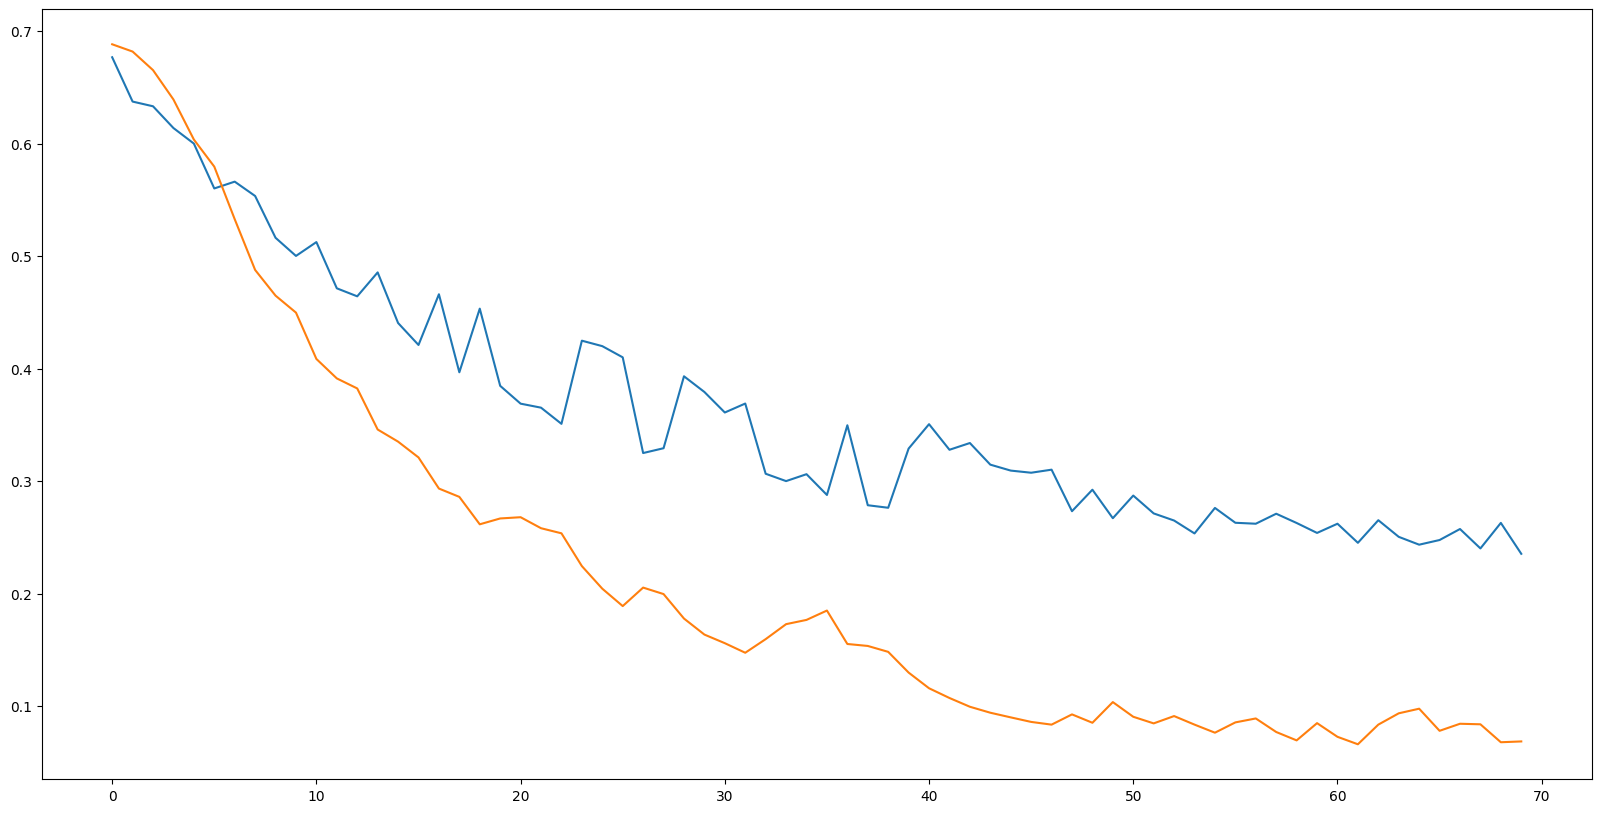

In [30]:
plt.figure(figsize=(20,10))
plt.plot(model.loss_train_history)
plt.plot(model.loss_test_history)
torch.save(model.model, 'model')

# d-CAM Class Activation Map


In [31]:
# predict
with torch.no_grad():
    logits = net(instance)
    if logits.ndim == 1 or logits.shape[-1] == 1:      # binary logit
        p1 = torch.sigmoid(logits.view(-1))[0].item()
        pred = int(p1 >= 0.5)
        probs = [1 - p1, p1]
    else:                                               # 2-class logits
        sm = torch.softmax(logits, dim=-1)[0]
        p1 = sm[1].item()
        pred = int(torch.argmax(sm).item())
        probs = sm.tolist()

print({"pred": pred, "probs": probs})

{'pred': 1, 'probs': [0.1343984752893448, 0.8656014800071716]}


In [32]:
# load the model
model = torch.load("model", map_location=device, weights_only=False).to(device)
model = model.eval() # NOTE: It does NOT disable autograd; use torch.no_grad() for that.
# net = getattr(model, "model", model).to(device).eval()

# dCNN
last_conv_layer = model._modules['layer3']
fc_layer_name = model._modules['fc1']

DCAM_m = DCAM(model,device,last_conv_layer=last_conv_layer,fc_layer_name=fc_layer_name)
dcam, permutation_success = DCAM_m.run(
    instance=[i for i in instance[0].cpu().numpy()[0]],
    nb_permutation=200,
    label_instance=target_label)

  0%|          | 0/200 [00:00<?, ?it/s]/home/tapyu/git/dCAM/examples/../src/explanation/DCAM.py:113: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  pred_probabilities = F.softmax(prediction).data.squeeze()
100%|██████████| 200/200 [00:10<00:00, 18.66it/s]


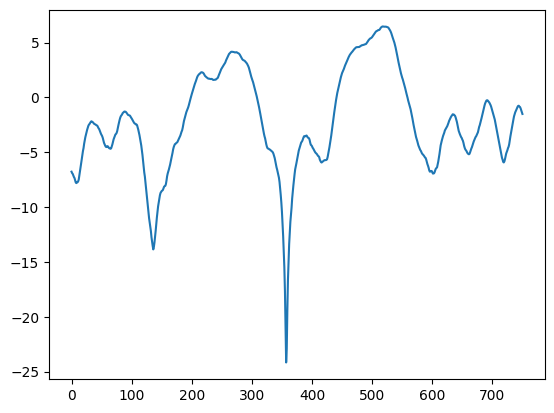

In [33]:
plt.plot(instance[0].cpu().numpy()[0][0, :])
plt.show()

# Plot for strong

/tmp/ipykernel_23662/44549271.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"Dim {i}"])
/tmp/ipykernel_23662/44549271.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"Dim {i}"])
/tmp/ipykernel_23662/44549271.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"Dim {i}"])
/tmp/ipykernel_23662/44549271.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"Dim {i}"])
/tmp/ipykernel_23662/44549271.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"Dim {i}"])


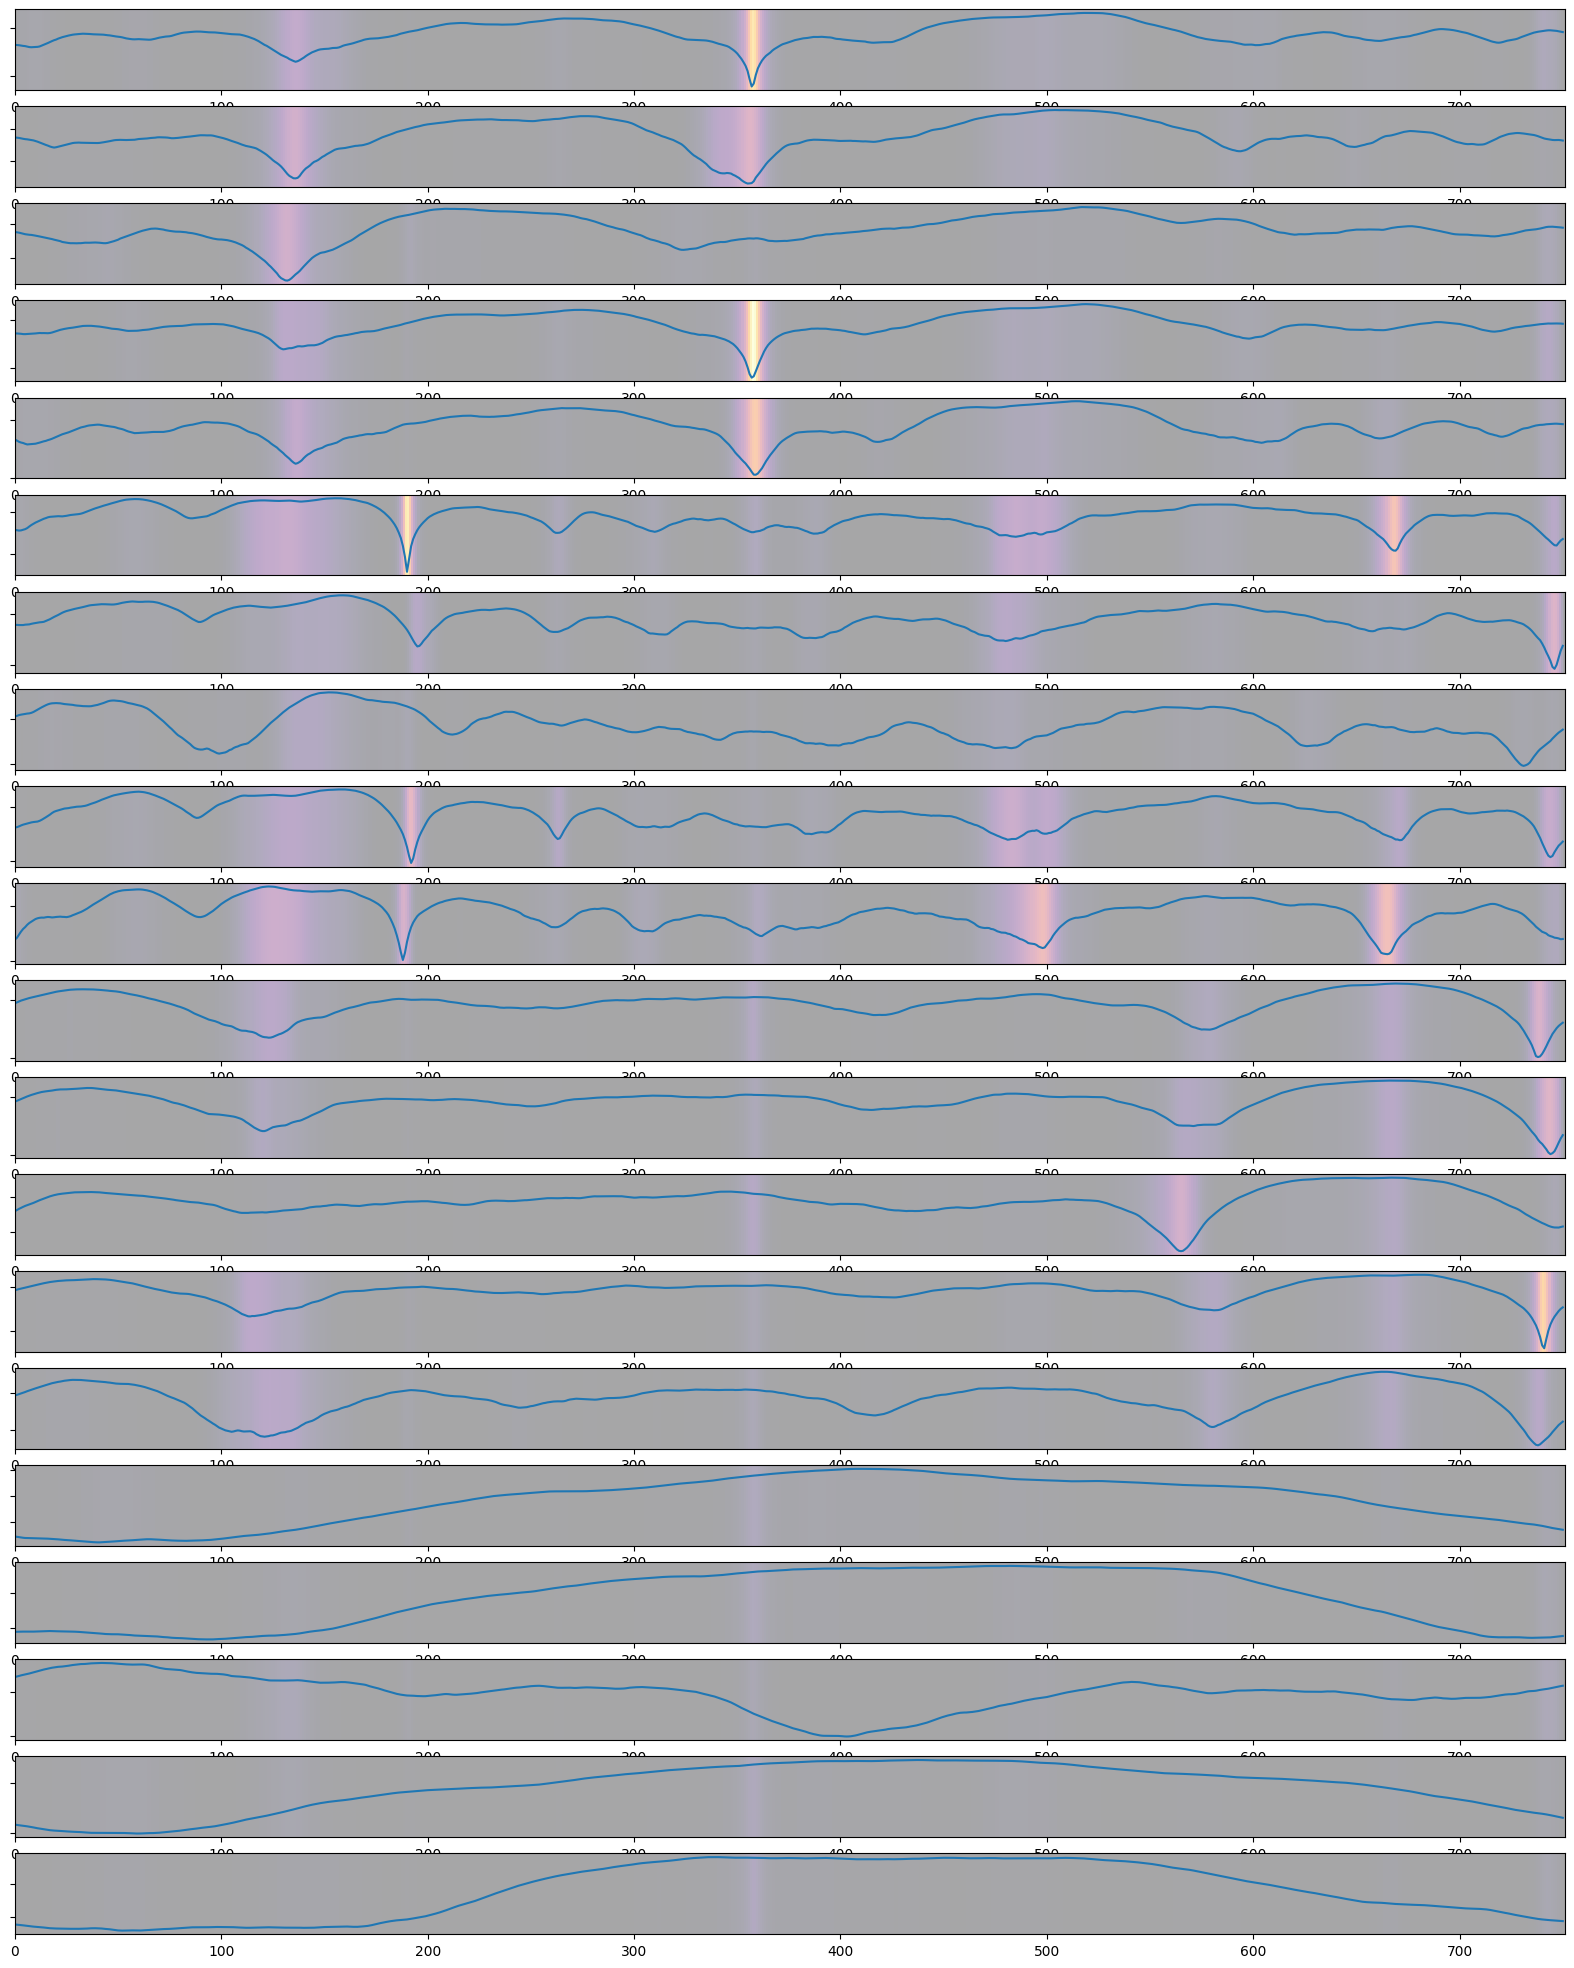

In [34]:
K = 20
dcam_min = np.min(dcam)
dcam_max = np.max(dcam)
dcam_range = dcam_max - dcam_min

dcam_norm = (dcam - dcam_min) / dcam_range
vmin, vmax = float(dcam_norm.min()), float(dcam_norm.max())

plt.figure(figsize=(20, 25))
for i in range(K):
    ax = plt.subplot(K, 1, i + 1)
    ax.plot(instance[0].cpu().numpy()[0][i, :], color="tab:blue")
    ax.set_xlim(0, len(instance[0].cpu().numpy()[0][i, :]))
    ax.set_yticklabels([f"Dim {i}"])

    ymin, ymax = ax.get_ylim()
    ax.imshow(
        dcam_norm[i][np.newaxis, :],
        extent=[0, len(dcam[i]), ymin, ymax],
        aspect="auto",
        cmap="inferno",
        alpha=0.35,
        vmin=vmin, vmax=vmax, # enforce global scaling
        interpolation="none",
    )
    ax.set_ylim(ymin, ymax)
